In [89]:
# Import the pandas library for data manipulation
import pandas as pd

In [90]:
# Load the housing dataset
df=pd.read_csv("data.csv")
print(df.head())

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    str

In [91]:
# Find correlation of each numeric feature with house price
corr = df.corr(numeric_only=True)["price"].sort_values(ascending=False)
print(corr)

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_built         0.021857
yr_renovated    -0.028774
Name: price, dtype: float64


In [92]:
# Fill missing numerical values with the mean
df = df.fillna(df.mean(numeric_only=True))

# Fill missing categorical values with the most frequent value
for col in df.select_dtypes(include="object"):
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\Sankalp\AppData\Local\Temp\ipykernel_18576\709482308.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [93]:
# Date features
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# House age
df["house_age"] = df["year"] - df["yr_built"]

# Renovation
df["is_renovated"] = (df["yr_renovated"] != 0).astype(int)

# Zip code
df["zipcode"] = df["statezip"].str[-5:]

# Dropping columns no longer needed
df.drop(
    ["date", "yr_built", "yr_renovated", "statezip", "country", "street"],
    axis=1,
    inplace=True
)

In [94]:
# Separate features and target variable
X = df.drop("price", axis=1)
y = df["price"]

# Convert categorical variables into dummy variables
X = pd.get_dummies(X, drop_first=True)


In [95]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=10
)


In [96]:
# Standardize the feature values
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test=scaler.transform(X_test)

In [97]:
# Train a Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_scaled_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [98]:
pred = model.predict(X_scaled_test)

print("R2:", model.score(X_scaled_test, y_test))

R2: 0.6010438399675861


In [99]:
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test, pred))

118400.46924015996


In [100]:
from sklearn.metrics import root_mean_squared_error

print(root_mean_squared_error(y_test, pred))

222645.19098092246


In [101]:
# Train a Random Forest model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=20
)

rf.fit(X_scaled_train, y_train)

print(rf.score(X_scaled_test, y_test))

0.5832073690777608


In [102]:
# Display Linear Regression coefficients
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": model.coef_
})

print(coef_df.sort_values("coef", ascending=False).head(10))

           feature           coef
8       sqft_above  112895.929206
2      sqft_living  107973.932316
48    city_Seattle   77688.210300
59   zipcode_98004   74146.095774
109  zipcode_98112   55422.492744
130  zipcode_98199   52426.649318
16   city_Bellevue   49447.014282
75   zipcode_98031   48773.173150
73   zipcode_98029   40408.079299
44    city_Redmond   39920.890928


In [103]:
# Train a Decision Tree model
from sklearn.tree import DecisionTreeRegressor

DTC=DecisionTreeRegressor()

DTC.fit(X_scaled_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [104]:
DTC.score(X_scaled_test,y_test)

0.40130664362128887

In [105]:
# Import additional regression models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Store all models in a dictionary for comparison

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

# Train and evaluate every model

for name, model in models.items():
    model.fit(X_scaled_train, y_train)

    r2 = model.score(X_scaled_test, y_test)

    print(f"{name}: {r2:.4f}")

Linear Regression: 0.6010
Ridge: 0.6012


c:\Users\Sankalp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.538e+14, tolerance: 1.405e+11
  model = cd_fast.enet_coordinate_descent(


Lasso: 0.6011
ElasticNet: 0.5921
Decision Tree: 0.2896
Random Forest: 0.6002
Gradient Boosting: 0.6347
AdaBoost: -0.2317
KNN: 0.5809
SVR: -0.0444


In [ ]:
#Found the best one for data i.e Gradient Boosting and making it more precise
from sklearn.ensemble import GradientBoostingRegressor

# Train the final Gradient Boosting model

gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

gb.fit(X_train, y_train)
print(gb.score(X_test, y_test))

0.668602199797613


In [107]:
pred = gb.predict(X_test)

# Evaluate the final model

print("R2:", gb.score(X_test, y_test))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", root_mean_squared_error(y_test, pred))

R2: 0.668602199797613
MAE: 102710.94644316798
RMSE: 202920.32167781427


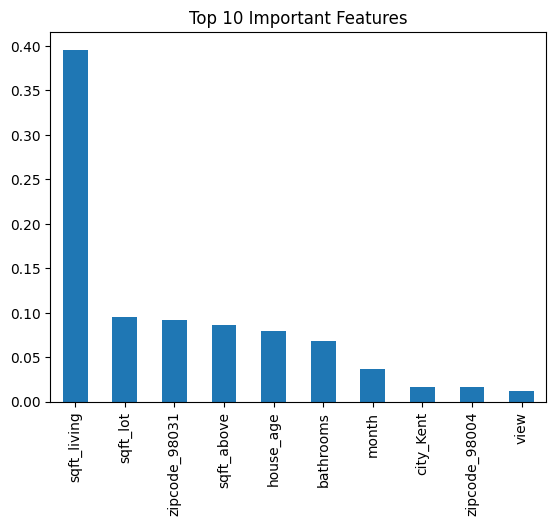

In [108]:
# Plot feature importance
import matplotlib.pyplot as plt

importance = pd.Series(
    gb.feature_importances_,
    index=X.columns
)

importance.nlargest(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.show()

In [109]:
# Predict the price of one sample house just for sample

pred = gb.predict(X_test.iloc[[0]])
print("Actual:", y_test.iloc[0])
print("Predicted:", pred[0])

Actual: 525000.0
Predicted: 442875.57387832104


In [110]:
# Verify prediction size

pred = gb.predict(X_test)

print(len(y_test))
print(len(pred))

460
460


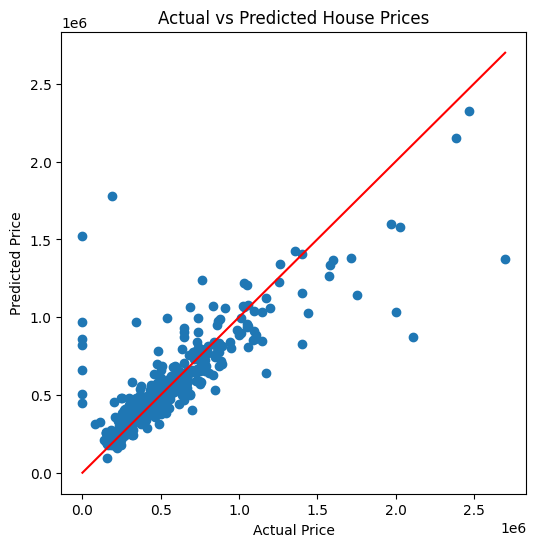

In [111]:
# Plot actual vs predicted prices

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

c:\Users\Sankalp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.538e+14, tolerance: 1.405e+11
  model = cd_fast.enet_coordinate_descent(


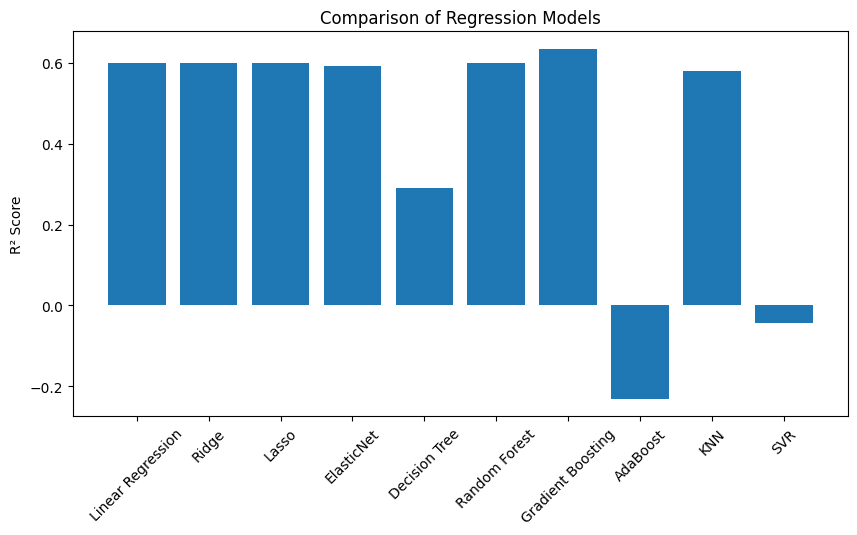

In [112]:
# Compare the performance of all regression models

scores = []

for name, model in models.items():
    model.fit(X_scaled_train, y_train)
    scores.append(model.score(X_scaled_test, y_test))

plt.figure(figsize=(10,5))
plt.bar(models.keys(), scores)
plt.xticks(rotation=45)
plt.ylabel("R² Score")
plt.title("Comparison of Regression Models")
plt.show()